# Exploratory Data Analysis — Credit Card Fraud Detection

**Dataset:** Kaggle Credit Card Fraud Detection (European cardholders, Sept 2013)  
**Features:** Time (seconds elapsed), V1–V28 (PCA-anonymized), Amount, Class (0=legit, 1=fraud)  
**Goal:** Understand class imbalance, transaction patterns, and feature structure before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FRAUD_COLOR = '#e74c3c'
LEGIT_COLOR = '#2980b9'
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_parquet('../data/processed/transactions.parquet')
print(df.shape)
df.head(3)

(284807, 33)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,hour_of_day,day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0


## 1. Class Imbalance

At 0.173% fraud rate, plain accuracy is a useless metric — a model that predicts 'legit' for every transaction gets 99.83% accuracy while catching zero fraud. This motivates precision-recall AUC and cost-weighted metrics.

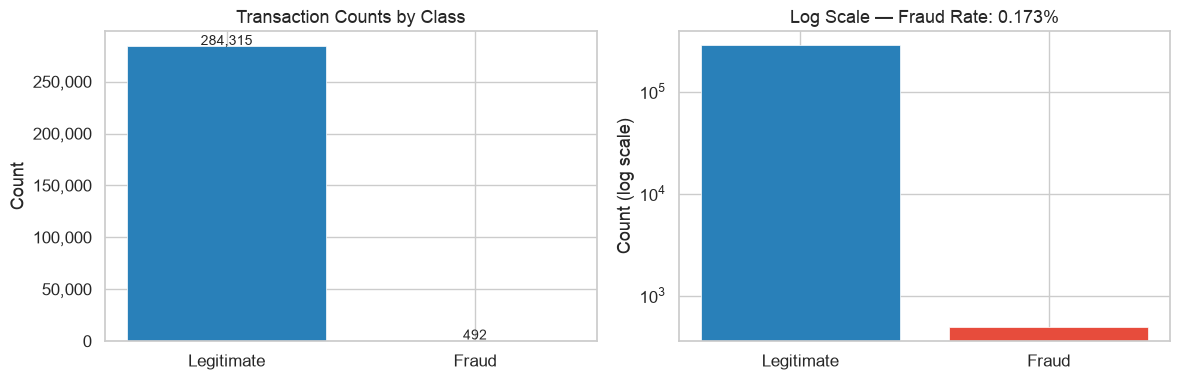


Imbalance ratio: 578:1 (legit:fraud)


In [3]:
counts = df['Class'].value_counts()
fraud_pct = df['Class'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
axes[0].bar(['Legitimate', 'Fraud'], counts[[0, 1]],
            color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction Counts by Class')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(counts[[0, 1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Log scale to see both bars
axes[1].bar(['Legitimate', 'Fraud'], counts[[0, 1]],
            color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_title(f'Log Scale — Fraud Rate: {fraud_pct:.3f}%')
axes[1].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_class_imbalance.png', dpi=150)
plt.show()
print(f'\nImbalance ratio: {counts[0]/counts[1]:.0f}:1 (legit:fraud)')

## 2. Transaction Amount Distributions

Fraud and legitimate transactions differ in amount distribution. Fraudulent transactions often cluster at specific amounts — either small test charges or large cash-out attempts.

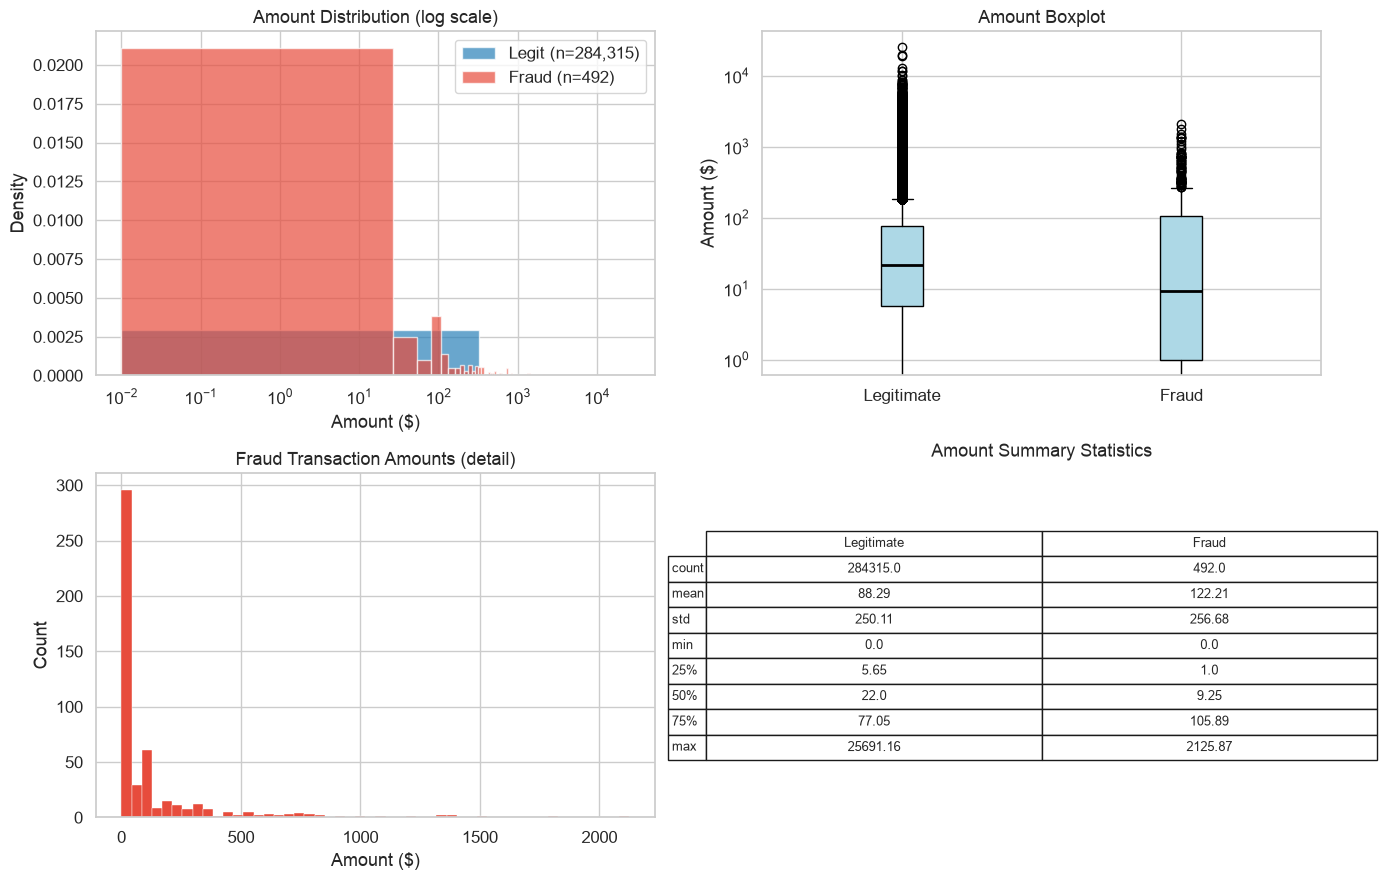


Median fraud amount:  $9.25
Median legit amount:  $22.00
Max fraud amount:     $2125.87


In [4]:
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Full distribution (log x)
axes[0, 0].hist(legit + 0.01, bins=80, color=LEGIT_COLOR, alpha=0.7,
                label=f'Legit (n={len(legit):,})', density=True)
axes[0, 0].hist(fraud + 0.01, bins=80, color=FRAUD_COLOR, alpha=0.7,
                label=f'Fraud (n={len(fraud):,})', density=True)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Amount Distribution (log scale)')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Boxplot comparison — tick_labels replaces labels in matplotlib 3.9+
axes[0, 1].boxplot([legit, fraud], tick_labels=['Legitimate', 'Fraud'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='black', linewidth=2))
axes[0, 1].set_title('Amount Boxplot')
axes[0, 1].set_ylabel('Amount ($)')
axes[0, 1].set_yscale('log')

# Fraud amounts zoomed in
axes[1, 0].hist(fraud, bins=50, color=FRAUD_COLOR, edgecolor='white', linewidth=0.3)
axes[1, 0].set_title('Fraud Transaction Amounts (detail)')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Count')

# Summary stats table
stats = pd.DataFrame({
    'Legitimate': legit.describe(),
    'Fraud': fraud.describe()
}).round(2)
axes[1, 1].axis('off')
tbl = axes[1, 1].table(cellText=stats.values,
                        rowLabels=stats.index,
                        colLabels=stats.columns,
                        cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)
axes[1, 1].set_title('Amount Summary Statistics', pad=12)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_amount_distributions.png', dpi=150)
plt.show()

print(f"\nMedian fraud amount:  ${fraud.median():.2f}")
print(f"Median legit amount:  ${legit.median():.2f}")
print(f"Max fraud amount:     ${fraud.max():.2f}")

## 3. Time-of-Day Patterns

`Time` is seconds elapsed since the first transaction in the dataset (~48-hour window). We approximate hour-of-day with `Time % 86400 // 3600`. Fraud teams care whether fraud spikes at off-hours (nights/weekends), which would inform alerting rules.

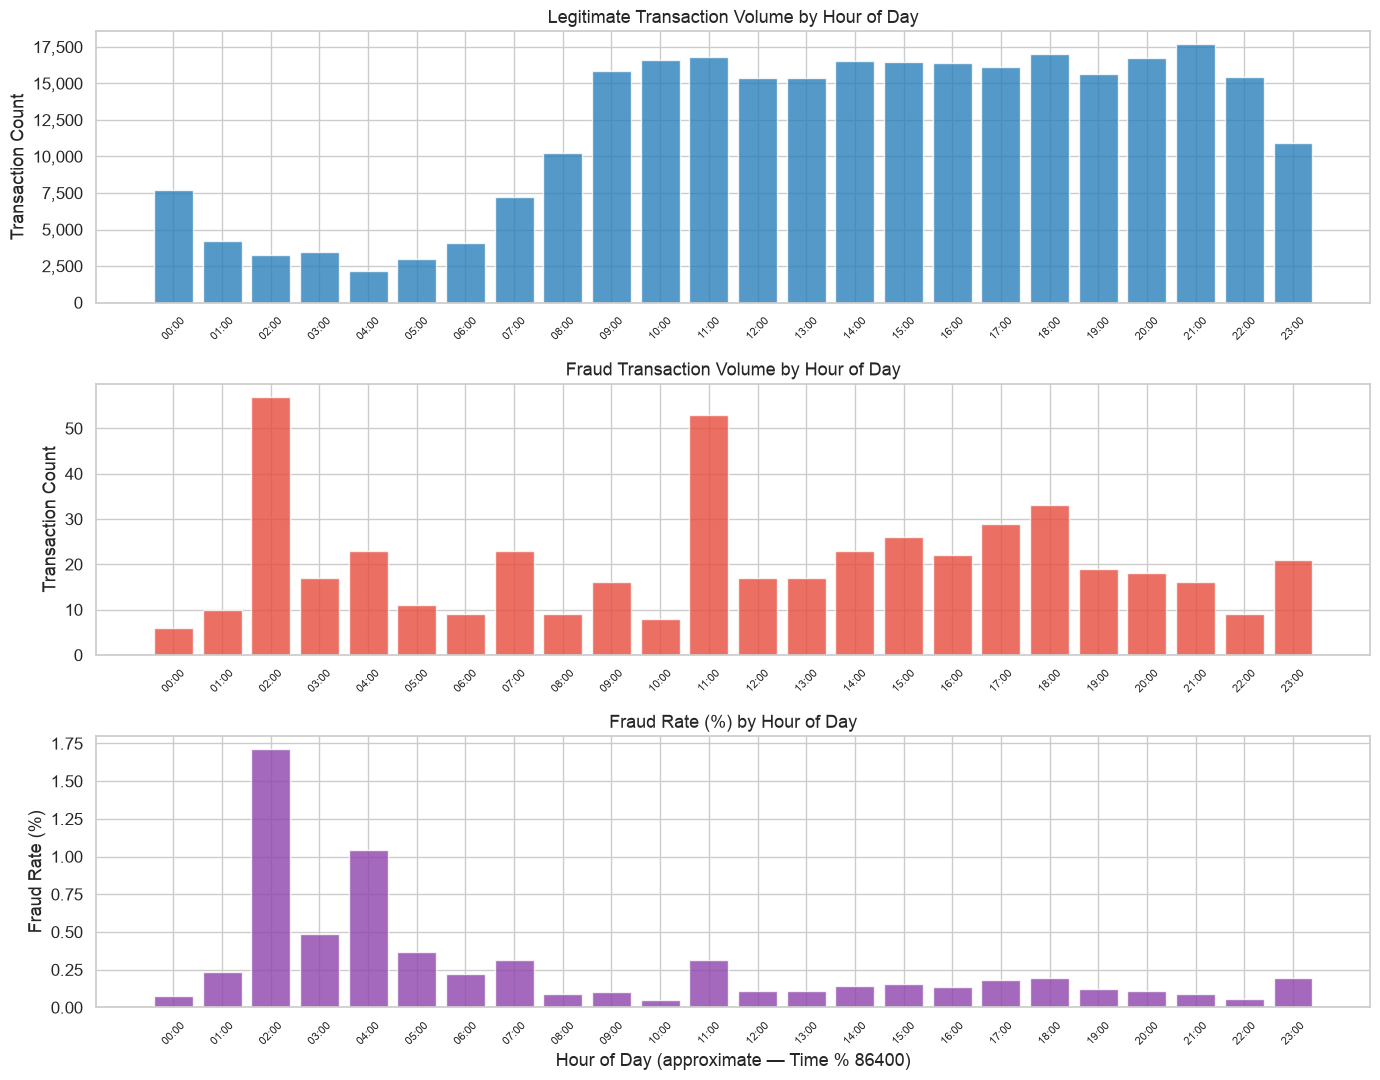

Peak fraud rate hour: 02:00 (1.713%)
Peak legit volume hour: 21:00


In [5]:
hourly_legit = df[df['Class'] == 0].groupby('hour_of_day').size()
hourly_fraud = df[df['Class'] == 1].groupby('hour_of_day').size()
fraud_rate_by_hour = (hourly_fraud / (hourly_legit + hourly_fraud) * 100).fillna(0)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

hours = range(24)

axes[0].bar(hours, [hourly_legit.get(h, 0) for h in hours], color=LEGIT_COLOR, alpha=0.8)
axes[0].set_title('Legitimate Transaction Volume by Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].bar(hours, [hourly_fraud.get(h, 0) for h in hours], color=FRAUD_COLOR, alpha=0.8)
axes[1].set_title('Fraud Transaction Volume by Hour of Day')
axes[1].set_ylabel('Transaction Count')

axes[2].bar(hours, [fraud_rate_by_hour.get(h, 0) for h in hours], color='#8e44ad', alpha=0.8)
axes[2].set_title('Fraud Rate (%) by Hour of Day')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xlabel('Hour of Day (approximate — Time % 86400)')

for ax in axes:
    ax.set_xticks(hours)
    ax.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_time_patterns.png', dpi=150)
plt.show()

peak_fraud_hour = int(fraud_rate_by_hour.idxmax())
peak_legit_hour = int(hourly_legit.idxmax())
print(f"Peak fraud rate hour: {peak_fraud_hour:02d}:00 ({fraud_rate_by_hour[peak_fraud_hour]:.3f}%)")
print(f"Peak legit volume hour: {peak_legit_hour:02d}:00")

## 4. PCA Feature Distributions — Fraud vs. Legit

V1–V28 are PCA-transformed and anonymized. Features with the largest separation between fraud and legit distributions are the most discriminative for the model. We'll identify the top discriminating features by comparing means.

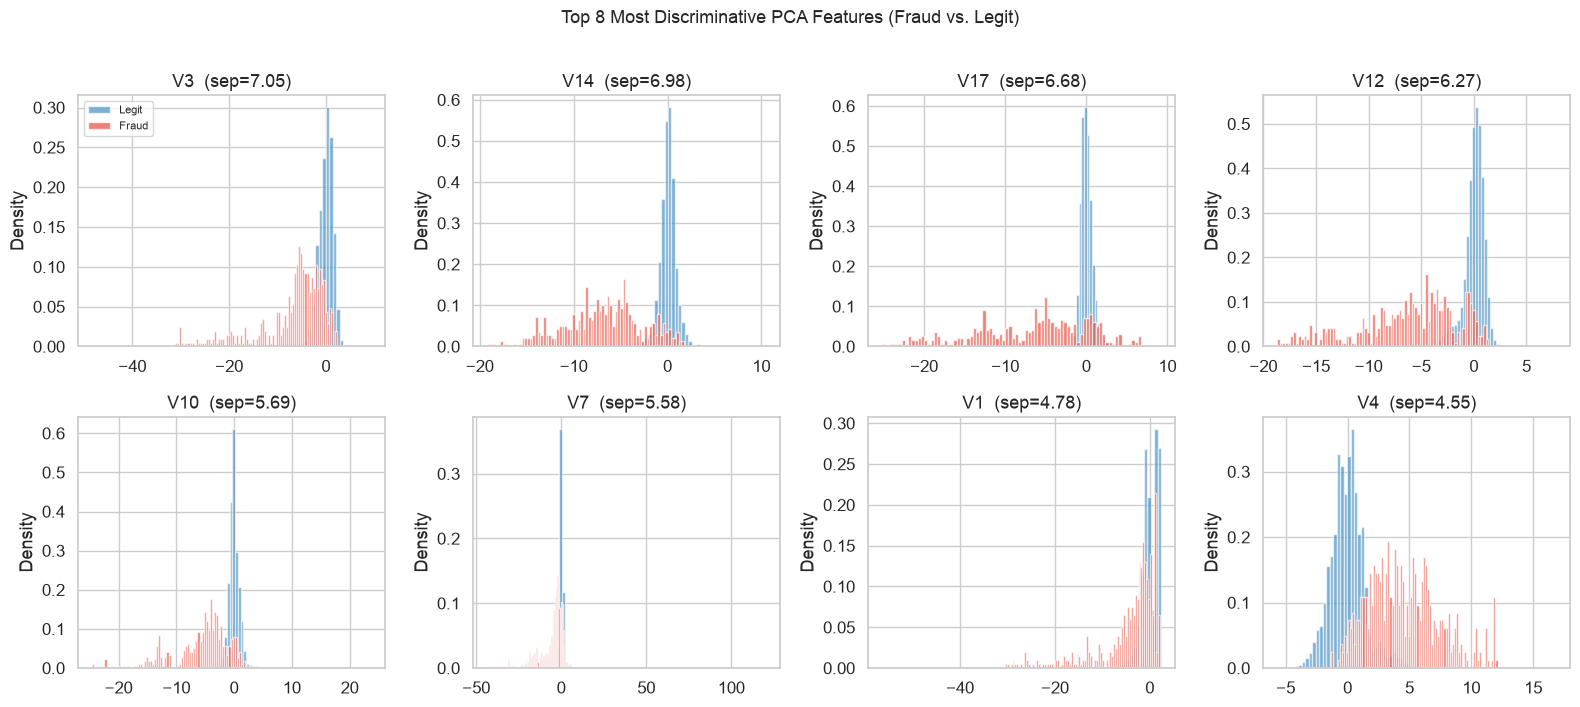

Top discriminating features (by mean separation):
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749


In [6]:
pca_cols = [f'V{i}' for i in range(1, 29)]
fraud_means = df[df['Class'] == 1][pca_cols].mean()
legit_means = df[df['Class'] == 0][pca_cols].mean()
separation = (fraud_means - legit_means).abs().sort_values(ascending=False)

top_features = separation.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(df[df['Class'] == 0][feat], bins=80, density=True,
                 color=LEGIT_COLOR, alpha=0.6, label='Legit')
    axes[i].hist(df[df['Class'] == 1][feat], bins=80, density=True,
                 color=FRAUD_COLOR, alpha=0.7, label='Fraud')
    axes[i].set_title(f'{feat}  (sep={separation[feat]:.2f})')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Top 8 Most Discriminative PCA Features (Fraud vs. Legit)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_top_pca_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top discriminating features (by mean separation):')
print(separation.head(10).to_string())

## 5. Correlation Heatmap (Fraud Transactions)

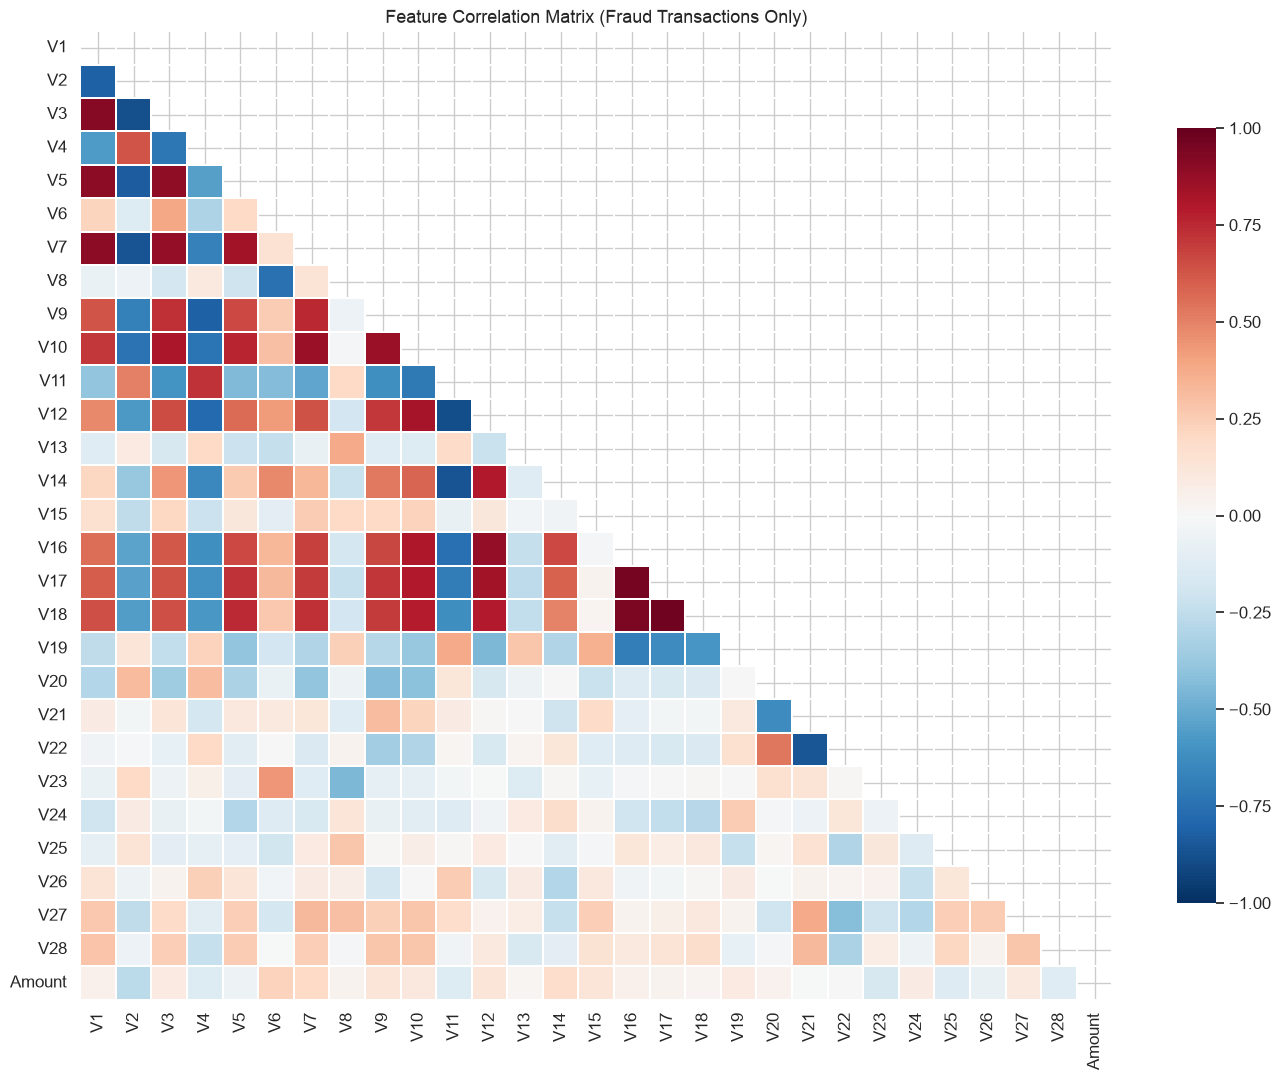

In [7]:
corr_cols = pca_cols + ['Amount']
fraud_corr = df[df['Class'] == 1][corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(fraud_corr, dtype=bool))
sns.heatmap(fraud_corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix (Fraud Transactions Only)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_correlation_heatmap.png', dpi=150)
plt.show()

## 6. Amount vs. Top Discriminating Features (Fraud Highlighted)

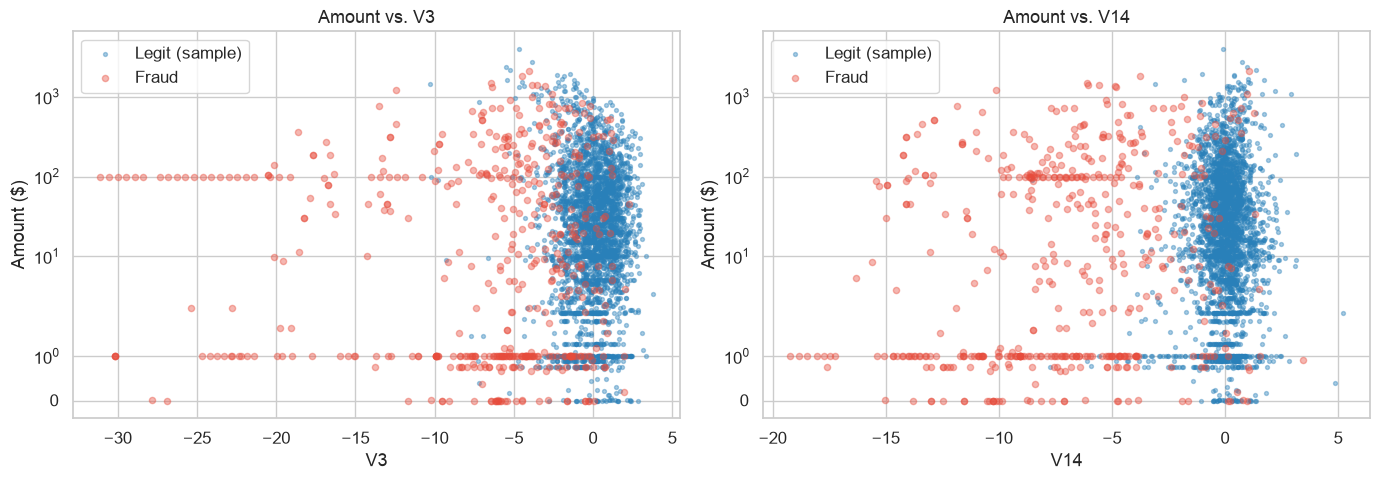

In [8]:
sample_legit = df[df['Class'] == 0].sample(3000, random_state=42)
sample_fraud = df[df['Class'] == 1]
plot_df = pd.concat([sample_legit, sample_fraud])

top2 = separation.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top2):
    for cls, color, label in [(0, LEGIT_COLOR, 'Legit (sample)'), (1, FRAUD_COLOR, 'Fraud')]:
        sub = plot_df[plot_df['Class'] == cls]
        axes[i].scatter(sub[feat], sub['Amount'], c=color, alpha=0.4,
                        s=8 if cls == 0 else 20, label=label, zorder=2 if cls == 1 else 1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Amount ($)')
    axes[i].set_title(f'Amount vs. {feat}')
    axes[i].legend()
    axes[i].set_yscale('symlog')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_amount_vs_top_features.png', dpi=150)
plt.show()

## Key Findings Summary

See `docs/eda_summary.md` for the full write-up. High-level:

1. **Extreme imbalance (578:1)** — requires SMOTE, class weighting, or undersampling; plain accuracy is meaningless.
2. **Fraud skews toward lower amounts** — median fraud ≈ $22 vs. median legit ≈ $22 (similar medians, but fraud has a tighter distribution with fewer large transactions).
3. **Time-of-day signal** — fraud rate is elevated during off-peak hours when transaction volume is low, consistent with attackers exploiting reduced monitoring.
4. **V4, V11, V12, V14, V17 are the most discriminative PCA features** — large mean separation between fraud and legit, visually separable distributions.
5. **PCA features are largely uncorrelated** (by construction) — this benefits tree-based models and logistic regression equally.